This notebook is to present yo you an example of how you can use the current version of the library in Python.In the report,you can find a description of the library.

Below, we will load a mesh of a slice of the library and simulate the forward problem with CEM(Complete Electrode Model).

If you wish you can simutale the inverse problem solution with the framework **pyeit**.I used **pyeit**  just to manipulate the meshes(that replaces writing my own class of meshes).At the end of this notebook I wrote an example of you can simultae forward and inverse problem with pyeit.I chose BP method.

You might want to simulate inverse problem solution with pyeit, after solving the forward problem with my ''solver'',since pyeit doesn't have CEM.Please know that **pyeit** removes some measurments in the forward problem(and so when simulating invere problem solution it doesnt expect all the measurments) and that my current ''solver'' just gives you ALL the measurments.So you need to adapt it(juste pick whaever measurements you want to consider in your measurment patterns). Please read this doc to understand more about what *pyeit* does for measurment/injection patterns: https://github.com/eitcom/pyEIT/blob/master/doc/pyEIT-data_format.pdf. You might  also want to write you own inverse solvers..


(https://github.com/eitcom/pyEIT)

In [1]:
import sys, os
import numpy as np
import argparse
import pickle
import matplotlib.pyplot as plt

In [2]:
from pyeit.mesh import PyEITMesh

def load_mesh_pkl(path):
    """
    Load a mesh from a pickle file.
    Parameters
    ----------
    path : str
        Path to the pickle file containing the mesh data.   
    Returns
    -------
    mesh : PyEITMesh
        The loaded mesh object.
    mask : np.ndarray               
        The mask of the mesh.
    boundary_edges : np.ndarray 
        edges forming the boundary of th mesh
    present_organs : list
        list of the organs present in the slice
        useful for applying conductivty values. since we don't want to fix them at the moment of generating the meshes, to be able to simulate with multiple
        conductivty values for the same library.
    slice_number : int
        index of slice in the original  3D CT
    z_min and z_max : int
        indexes of slices limiting the torso zone in the original 3D CT 

        the last three returns were useful in the solution by search to limit the number of slices where we would look for similiraty in EIT measuments.
        say we want to reconstuct slice 50 of case 0011, we would only search for slices in the other cases who are in same zone, so we need to know the
        index of a slice to know if we want to consider it or not in the solution by search, and z_min and z_max because the subjects dont have the same number of slices in the torso zone.

    """
    with open(path,"rb") as f:
        d = pickle.load(f)
    mesh = PyEITMesh(node=d["node"],
                     element=d["element"],
                     el_pos=d["el_pos"])
    mesh.perm = d["perm"]
    return mesh, d["mask"],d["boundary_edges"],d["present_organs"],d["slice_number"],d["z_min"],d["z_max"]



In [ ]:
case = "s0059"  
slice_number =  100 ## some subject and slice.make sure to place them in the folder Python_library, "s0059" is already there
meshA,maskA,barsA,present_organsA,z,z_min,z_max = load_mesh_pkl(f"Python_library/{case}/{case}_mesh_slice_{slice_number}.pkl") ## Adapt the path to your mesh file



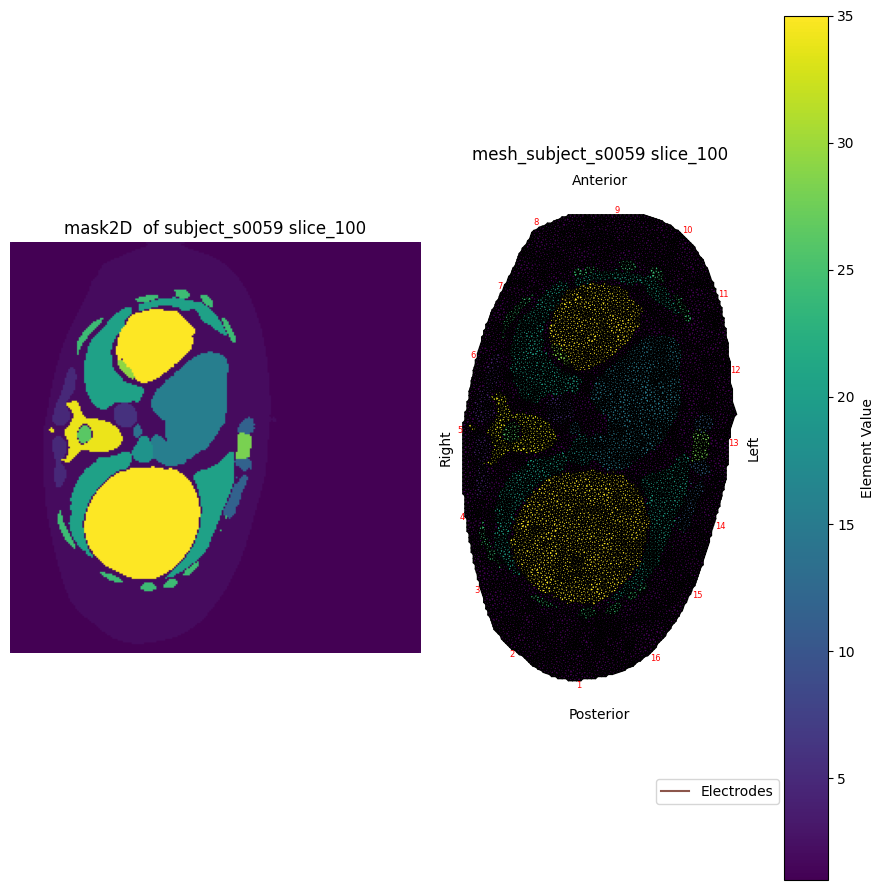

In [4]:
## plot
from pyeit.visual.plot  import create_mesh_plot, create_plot

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(9, 9))

ax0.imshow(maskA, cmap='viridis')
ax0.set_title(f"mask2D  of subject_{case} slice_{slice_number}")
ax0.axis("off")
  
create_mesh_plot(
                    ax1,meshA,
                    electrodes=meshA.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
)
ax1.set_title(f"mesh_subject_{case} slice_{slice_number}")
ax1.axis("off")

plt.tight_layout()
plt.show()

**A detail** :  You can see in the figure above at right that there are small digits in red; they should present the placement of electrodes.Please understand that is only artificial(at this point we didnt say anythig about EIT) because *pyeit* does it by default when defining a mesh.

For example, belwow I will tell *pyeit* to show all the points of the boundary of the mesh.

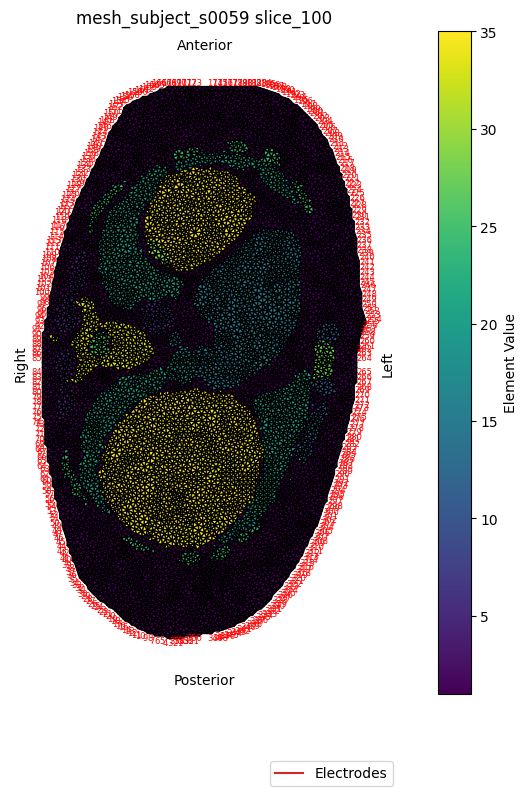

In [5]:
fig, ax0 = plt.subplots(1, 1, figsize=(8,8))

create_mesh_plot(
                    ax0,meshA,
                    electrodes=np.arange(len(barsA)),
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
)
ax0.set_title(f"mesh_subject_{case} slice_{slice_number}")
ax0.axis("off")

plt.tight_layout()
plt.show()

Below is an example of solving the forward problem with CEM(Complete Electrode Model). OOEIT does it in Matlab.We didn't find the CEM in an avalaible framework in Python, so I did it(based on this  https://www.researchgate.net/publication/12807310_Three-dimensional_electrical_impedance_tomography_based_on_the_complete_electrode_model) but it needs to be optimized.

First we set some realistic values for conuductivity:

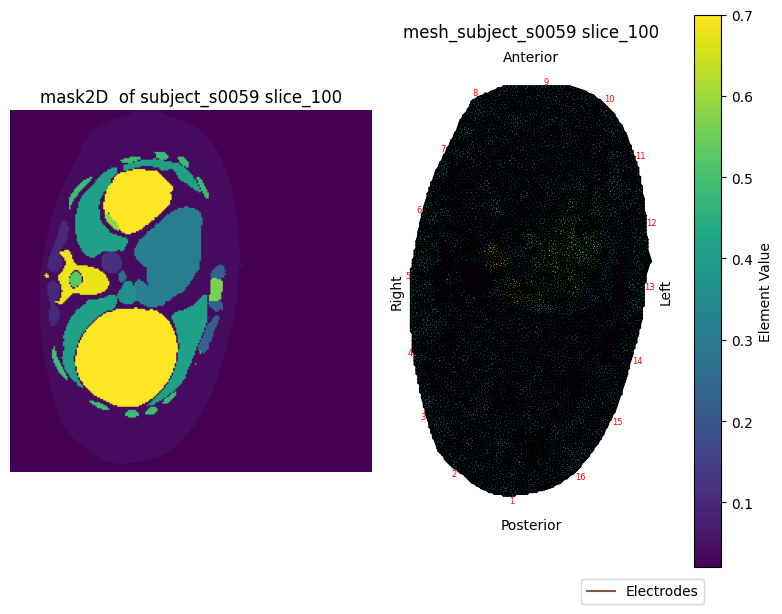

In [6]:

cond_table = {
        'soft_tissue': 0.30,
        'adrenal_gland': 0.25,
        'autochthon': 0.40,
        'clavicula': 0.02,
        'costal_cartilages': 0.08,
        'ribs': 0.05,
        'scapula': 0.02,
        'sternum': 0.02,
        'skull': 0.02,
        'humerus': 0.02,
        'femur': 0.02,
        'vertebrae': 0.02,
        'sacrum': 0.02,
        'gluteus_maximus': 0.40,
        'gluteus_minimus': 0.40,
        'gluteus_medius': 0.40,
        'iliopsoas': 0.40,
        'hip': 0.08,
        'iliac_arterie': 0.70,
        'iliac_vein': 0.70,
        'brachiocephalic_trunk': 0.70,
        'brachiocephalic_vein': 0.70,
        'common_carotid_artery': 0.70,
        'subclavian_artery': 0.70,
        'aorta': 0.70,
        'superior_vena_cava': 0.70,
        'inferior_vena_cava': 0.70,
        'portal_and_splenic_vein': 0.70,
        'pulmonary_vein': 0.70,
        'trachea': 0.15,
        'lung': 0.15,
        'heart': 0.50,
        'atrial_appendage': 0.20,
        'esophagus': 0.40,
        'stomach': 0.40,
        'duodenum': 0.40,
        'small_bowel': 0.40,
        'colon': 0.40,
        'liver': 0.20,
        'gallbladder': 0.15,
        'pancreas': 0.15,
        'spleen': 0.20,
        'thyroid_gland': 0.50,
        'kidney': 0.35,
        'kidney_cyst': 1.50,
        'urinary_bladder': 1.50,
        'prostate': 0.35,
        'spinal_cord': 0.30,
    }


def sig_update(org_list, sig):
    
    # build master list
    master_names = ['soft_tissue'] + list(org_list)

    master_values = []
    for name in master_names:
        if name not in cond_table:
            raise ValueError(f"No conductivity defined for '{name}'")
        master_values.append(cond_table[name])
    master_values = np.array(master_values)

    # Adjust labels (1-based : 0-based) 
    sig_idx = np.asarray(sig, dtype=int) - 1  

    # check for out-of-range
    if sig_idx.max() >= len(master_values) or sig_idx.min() < 0:
        raise IndexError("Some labels in 'sig' exceed available mapping")

    sigma_real = master_values[sig_idx]

    return sigma_real

sig_real = sig_update(present_organsA, meshA.perm)
meshA.perm =sig_real


fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(8, 6))

ax0.imshow(maskA, cmap='viridis')
ax0.set_title(f"mask2D  of subject_{case} slice_{slice_number}")
ax0.axis("off")
  

create_mesh_plot(
                    ax1,meshA,
                    electrodes=meshA.el_pos,
                    coordinate_labels="radiological",
                    marker_text_kwargs={"color": "red", "fontsize": 6}
)
ax1.set_title(f"mesh_subject_{case} slice_{slice_number}")
ax1.axis("off")

plt.tight_layout()
plt.show()


Below is example of how to solve the forward problem with CEM with my ""solver"":


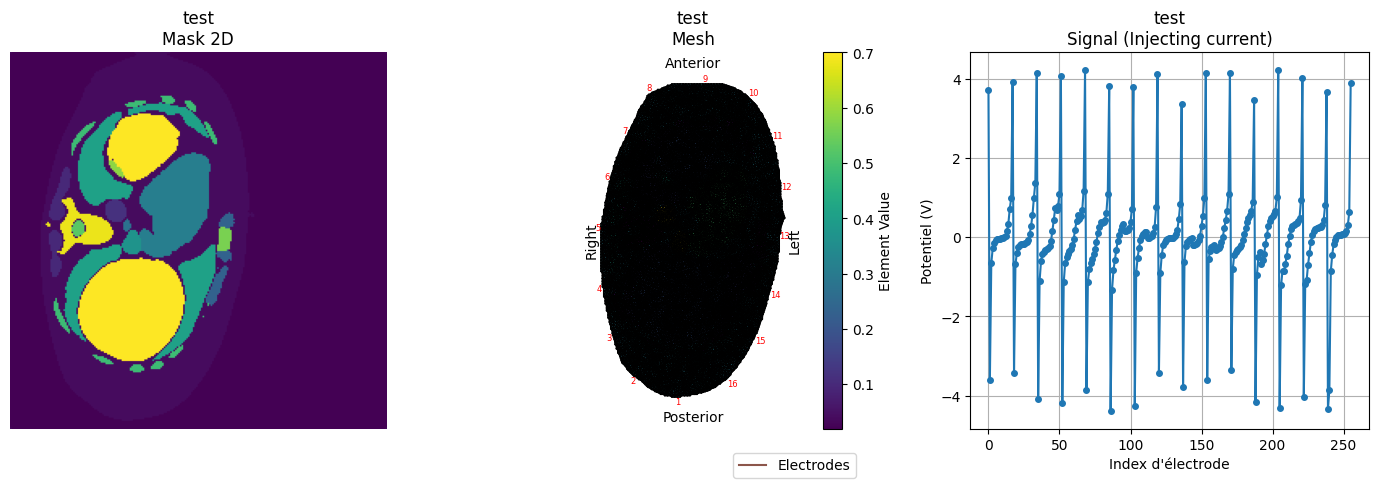

In [41]:
## Example of solving a forward problem with  with CEM
from src.EIT_sim import solve_and_plot, set_protocol



protocol_ref = set_protocol(n_el=meshA.n_el,
                                dist_exc=1,
                                step_meas=1)  ##set injection/measurment protocl. As I mentionned at the beginning of the notebook,my "solver" gives you all
                                              ## the measures,so  this line is just to define number of electrodes.Please read here to understand what does
                                              ## dist_exc and step_meas mean : https://github.com/eitcom/pyEIT/blob/master/doc/pyEIT-data_format.pdf

# Solve plot de la référence
sol_ref = solve_and_plot(
        meshA,barsA, maskA,
        meshA.perm, protocol_ref,
        1e-5, "current",  ## 1e-5 is the contact impendece of the electrodes and "current" means we are injecting current
        title="test"
)



You have seen that in nowhere I allowed to chose number of electrodes.That is because there are fixed WITH the object PyEITMesh once it is defined.

The initial goal was to add my ""solver"" to pyeit because it doesn't have CEM, that is why I wrote my ""solve"" 'on' *pyeit*.
So to simulate with a differant number of electrodes, we have to create a new mesh(with the same nodes and triangles), but with juste a diffrenet number of electordes.My ""solver"" will then build the elecrodes.(see the cell below)

Finally, my actual ""solver"" doesn't allow to change the length of electrodes, their lenght is by default 2 edges.However, I did do it in Matlab(as you can see in the driver Driver_test_OOEIT.m; you can choose the length of electodes in cm).

<class 'numpy.ndarray'>


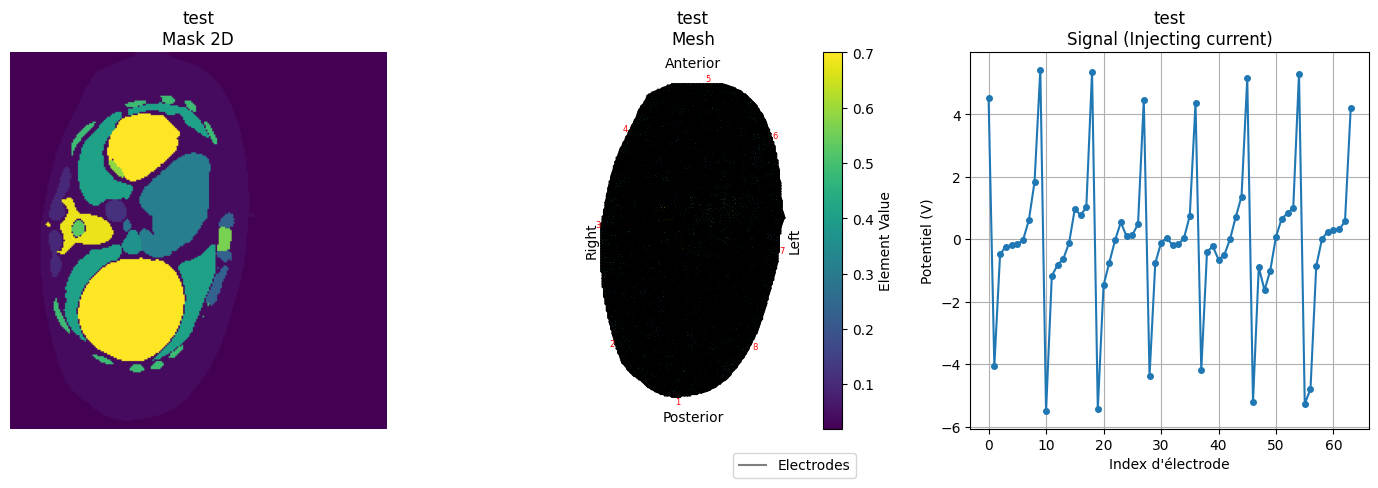

In [42]:
def place_electrodes_from_index_list(Nb, n_el):
    """
    Nb   : number of boundary segments (len(barsA))
    n_el : number of electrodes desired
    returns indices in [0, Nb-1] where electrodes are placed
    """
    
    return (np.linspace(0, Nb, n_el, endpoint=False)).astype(int)


n_el = 8
mesh_new,mesh_new.perm  = PyEITMesh(meshA.node,meshA.element,el_pos=place_electrodes_from_index_list(len(barsA),n_el)),meshA.perm   ##same mesh,just a different number of electodes

print(type(meshA.el_pos))

protocol_new = set_protocol(n_el=mesh_new.n_el,
                                dist_exc=1,
                                step_meas=1)
sol_ref = solve_and_plot(
        mesh_new,barsA, maskA,
        mesh_new.perm, protocol_new,
        1e-5, "current",  ## 1e-5 is the contact impendece of the electrodes and "current" means we are injecting current
        title="test"
)

A small example of usage of pyeit to solve forward then inverse problem is below.I chose BP method.You can try other methods, but it juste to show you how our meshes can easilly be integrated in pyeit solvers:

v0 shape: (208,) v1 shape: (208,)
ds shape: (7137,)


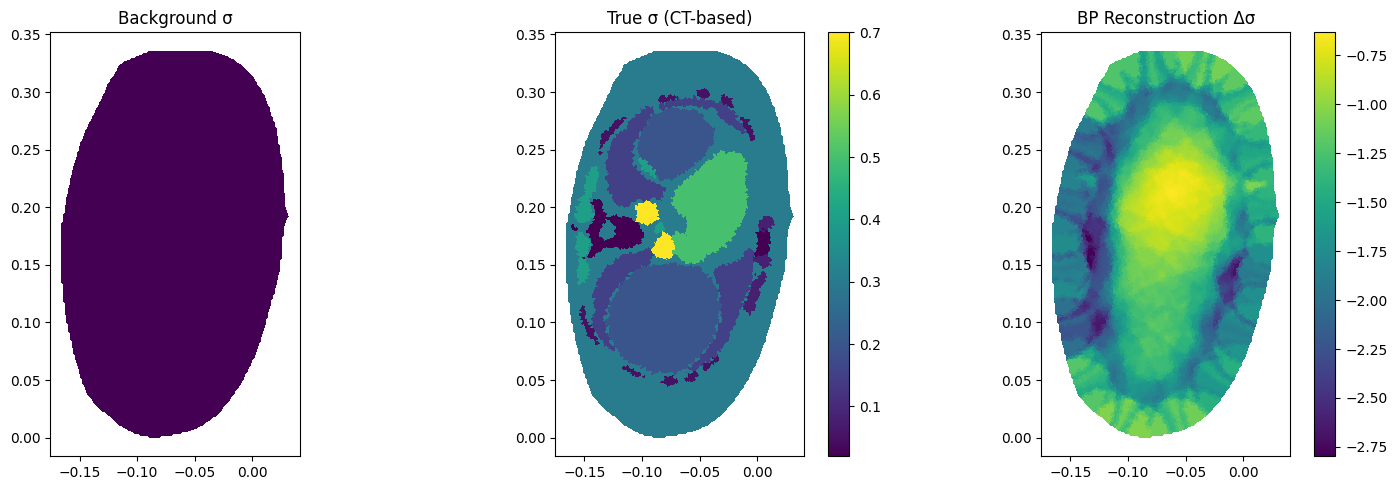

In [43]:

# baseline: homogeneous
perm_bg = np.ones(meshA.element.shape[0], dtype=float)

# "true" distribution: 
perm_true = np.array(meshA.perm, dtype=float)


import pyeit.eit.protocol as protocol
n_el = meshA.n_el
protocol_obj = protocol.create(
    n_el=n_el,
    dist_exc=1,      # adjacent stimulation
    step_meas=1,     # adjacent measurements
    parser_meas="std"
)
from pyeit.eit.fem import EITForward
fwd = EITForward(meshA, protocol_obj)

# reference (homogeneous)
v0 = fwd.solve_eit(perm=perm_bg)
# perturbed (CT-based conductivity)
v1 = fwd.solve_eit(perm=perm_true)

print("v0 shape:", v0.shape, "v1 shape:", v1.shape)

import pyeit.eit.bp as bp

eit_bp = bp.BP(meshA, protocol_obj)
eit_bp.setup(weight="none")

# reconstruct Δσ v1 − v0
ds = eit_bp.solve(v1, v0, normalize=True)  
print("ds shape:", ds.shape)


import matplotlib.pyplot as plt

pts = meshA.node
tri = meshA.element

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1) background (for reference)
ax = axes[0]
ax.tripcolor(pts[:, 0], pts[:, 1], tri, perm_bg, shading="flat")
ax.set_title("Background σ")
ax.set_aspect("equal")

# 2) true conductivity
ax = axes[1]
im1 = ax.tripcolor(pts[:, 0], pts[:, 1], tri, perm_true, shading="flat")
ax.set_title("True σ (CT-based)")
ax.set_aspect("equal")
fig.colorbar(im1, ax=ax)

# 3) BP reconstruction 
ax = axes[2]
im2 = ax.tripcolor(pts[:, 0], pts[:, 1], tri, ds, shading="flat")
ax.set_title("BP Reconstruction Δσ")
ax.set_aspect("equal")
fig.colorbar(im2, ax=ax)

plt.tight_layout()
plt.show()


With perm_bg = 1 and a full CT-based conductivity map as perm_true,BP gives a poor reconstruction.BP assumes a small and localized variations of conductivity around a homogeneous background, but the values of our CT map produce large variations across the entire torso.that example is juste to verify the forward/inverse pipeline works on our meshes.You can try with the other methods that offers **pyeit** ,but I don't think they give better results. your future work on bayesian EIT will certainly do :-)